# 🚁 DIP Project — Gün 13: GPU VRAM + GFLOPs Profiling
Pipeline'ın her aşamasında VRAM kullanımını ve GFLOPs'u ölç.

**Ölçülen bileşenler:**
- YOLOv8 (standalone)
- YOLOv8 + SAHI
- YOLOv8 + ByteTrack
- Tam pipeline (YOLOv8 + SAHI + ByteTrack)

In [1]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(args))

pip('numpy>=1.23,<2', '--force-reinstall')
pip('ultralytics>=8.3.0', 'sahi==0.11.15', 'supervision>=0.21.0', 'thop')

print('=' * 55)
print('✅ Kurulum tamam!')
print()
print('  >>> Runtime > Restart Runtime yap <<<')
print('  Restart sonrası bu hücreyi ATLA, sonrakinden başla!')
print('=' * 55)

✅ Kurulum tamam!

  >>> Runtime > Restart Runtime yap <<<
  Restart sonrası bu hücreyi ATLA, sonrakinden başla!


In [1]:
MODEL_PATH   = '/content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt'
PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'
YAML_PATH   = f'{PROJECT_DIR}/data.yaml'
import os
print('MODEL_PATH:', MODEL_PATH)
print('Dosya var mı:', os.path.exists(MODEL_PATH))


MODEL_PATH: /content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt
Dosya var mı: False


In [2]:
# ▶️ Restart sonrası buradan başla
import torch, os, cv2, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction, get_prediction
import supervision as sv

assert torch.cuda.is_available(), '❌ GPU gerekli!'
GPU_NAME   = torch.cuda.get_device_name(0)
TOTAL_VRAM = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'✅ GPU  : {GPU_NAME}')
print(f'   VRAM: {TOTAL_VRAM:.1f} GB')

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR  = '/content/drive/MyDrive/DIP_Project'
DATASET_ROOT = f'{PROJECT_DIR}/datasets/VisDrone'
DEVICE       = 'cuda'

meta_path = f'{PROJECT_DIR}/model_paths.json'
if os.path.exists(meta_path):
    with open(meta_path) as f:
        MODEL_PATH = json.load(f)['best_model']
else:
    MODEL_PATH = 'yolov8n.pt'
    print('⚠️  Gün 5 modeli bulunamadı — yolov8n.pt ile devam')

val_dir = Path(f'{DATASET_ROOT}/images/val')
if val_dir.exists():
    test_imgs = [str(f) for f in sorted(val_dir.glob('*.jpg'))[:30]]
else:
    import urllib.request
    urllib.request.urlretrieve('https://ultralytics.com/images/zidane.jpg', '/content/test.jpg')
    test_imgs = ['/content/test.jpg'] * 30
    print('⚠️  Fallback görüntü kullanılıyor')

print(f'✅ Test görüntü sayısı: {len(test_imgs)}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ GPU  : Tesla T4
   VRAM: 15.6 GB
Mounted at /content/drive
✅ Test görüntü sayısı: 30


## 1️⃣ GFLOPs Hesaplama — YOLOv8 Modeli

In [4]:
from thop import profile, clever_format

MODEL_PATH = '/content/drive/MyDrive/DIP_Project/runs/yolov8s_visdrone_v1/weights/best.pt'

model    = YOLO(MODEL_PATH)
pt_model = model.model.to(DEVICE)

dummy = torch.zeros(1, 3, 640, 640).to(DEVICE)


try:
    macs, params = profile(pt_model, inputs=(dummy,), verbose=False)
    gflops       = macs * 2 / 1e9   # MACs * 2 = FLOPs
    n_params_m   = params / 1e6
    print(f'✅ GFLOPs  : {gflops:.2f}')
    print(f'   Params  : {n_params_m:.2f}M')
    macs_str, params_str = clever_format([macs, params], '%.2f')
    print(f'   MACs    : {macs_str}')
    print(f'   Params  : {params_str}')
except Exception as e:
    print(f'⚠️  thop başarısız: {e}')
    # Ultralytics built-in fallback
    info = model.info(verbose=False)
    gflops    = 0.0
    n_params_m= 0.0
    print('   ultralytics.info() kullanıldı')

gflops_yolo   = gflops
params_m_yolo = n_params_m

✅ GFLOPs  : 28.67
   Params  : 11.14M
   MACs    : 14.33G
   Params  : 11.14M


## 2️⃣ VRAM Profiling Fonksiyonu

In [5]:
def get_vram_mb() -> float:
    """Anlık GPU bellek kullanımı (MB)."""
    torch.cuda.synchronize()
    return torch.cuda.memory_allocated() / 1e6

def get_peak_vram_mb() -> float:
    """Peak GPU bellek kullanımı (MB)."""
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1e6


def benchmark_component(name: str, fn, n_runs=20, warmup=3) -> dict:
    """Verilen fonksiyonu benchmark et — latency + VRAM."""
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    vram_before = get_vram_mb()

    # Warmup
    for _ in range(warmup):
        fn()

    torch.cuda.reset_peak_memory_stats()
    latencies = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        fn()
        torch.cuda.synchronize()
        latencies.append((time.perf_counter() - t0) * 1000)

    peak_vram = get_peak_vram_mb()
    avg_ms    = np.mean(latencies)
    std_ms    = np.std(latencies)
    fps       = 1000.0 / avg_ms

    print(f'  [{name:<35}]  {avg_ms:6.1f}±{std_ms:.1f}ms  |  {fps:5.1f} FPS  |  VRAM peak: {peak_vram:.1f}MB')
    return {
        'Component':   name,
        'Avg (ms)':    round(avg_ms,    2),
        'Std (ms)':    round(std_ms,    2),
        'FPS':         round(fps,       1),
        'VRAM peak (MB)': round(peak_vram, 1),
    }

print('✅ Benchmark fonksiyonu hazır!')

✅ Benchmark fonksiyonu hazır!


## 3️⃣ Her Bileşeni Ayrı Ayrı Benchmark Et

In [7]:
sahi_model = AutoDetectionModel.from_pretrained(
    model_type='yolov8',
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device=DEVICE,
)

byte_tracker = sv.ByteTrack(
    track_activation_threshold=0.25,
    lost_track_buffer=30,
    minimum_matching_threshold=0.8,
    frame_rate=30,
)

# Test görüntüsünü önceden yükle
test_frame = cv2.imread(test_imgs[0])
test_frame_rgb = cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB)

results_table = []
print('\nBenchmark başlıyor...\n')

# 1. Preprocessing
def preprocess_fn():
    cv2.resize(test_frame, (640, 640))

results_table.append(benchmark_component('Preprocessing (resize 640)', preprocess_fn))

# 2. YOLOv8 standalone
def yolo_fn():
    model.predict(test_frame, conf=0.25, device=DEVICE, verbose=False)

results_table.append(benchmark_component('YOLOv8 (no SAHI)', yolo_fn))

# 3. YOLOv8 + SAHI
def yolo_sahi_fn():
    get_sliced_prediction(
        test_imgs[0], sahi_model,
        slice_height=640, slice_width=640,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        verbose=0,
    )

results_table.append(benchmark_component('YOLOv8 + SAHI (640×640 20%)', yolo_sahi_fn, n_runs=10))

# 4. ByteTrack only (with pre-computed detections)
det_result  = model.predict(test_frame, conf=0.25, device=DEVICE, verbose=False)[0]
dets        = sv.Detections(
    xyxy       = det_result.boxes.xyxy.cpu().numpy(),
    confidence = det_result.boxes.conf.cpu().numpy(),
    class_id   = det_result.boxes.cls.cpu().numpy().astype(int),
)

def track_fn():
    byte_tracker.update_with_detections(dets)

results_table.append(benchmark_component('ByteTrack only', track_fn))

# 5. Full pipeline
def full_pipeline_fn():
    r       = model.predict(test_frame, conf=0.25, device=DEVICE, verbose=False)[0]
    d       = sv.Detections(
        xyxy       = r.boxes.xyxy.cpu().numpy(),
        confidence = r.boxes.conf.cpu().numpy(),
        class_id   = r.boxes.cls.cpu().numpy().astype(int),
    )
    byte_tracker.update_with_detections(d)

results_table.append(benchmark_component('Full Pipeline (YOLO+Track)', full_pipeline_fn))

print('\n✅ Benchmark tamamlandı!')


Benchmark başlıyor...

  [Preprocessing (resize 640)         ]     1.4±0.1ms  |  696.5 FPS  |  VRAM peak: 94.8MB
  [YOLOv8 (no SAHI)                   ]    13.1±1.8ms  |   76.1 FPS  |  VRAM peak: 151.6MB
  [YOLOv8 + SAHI (640×640 20%)        ]   541.7±95.4ms  |    1.8 FPS  |  VRAM peak: 167.2MB
  [ByteTrack only                     ]     9.5±0.8ms  |  105.6 FPS  |  VRAM peak: 129.3MB
  [Full Pipeline (YOLO+Track)         ]    24.5±1.1ms  |   40.8 FPS  |  VRAM peak: 152.5MB

✅ Benchmark tamamlandı!


## 4️⃣ Latency Breakdown Pasta Grafiği


📊 Profiling Tablosu:
                  Component  Avg (ms)  Std (ms)   FPS  VRAM peak (MB)
 Preprocessing (resize 640)      1.44      0.08 696.5            94.8
           YOLOv8 (no SAHI)     13.13      1.79  76.1           151.6
YOLOv8 + SAHI (640×640 20%)    541.73     95.40   1.8           167.2
             ByteTrack only      9.47      0.83 105.6           129.3
 Full Pipeline (YOLO+Track)     24.50      1.11  40.8           152.5


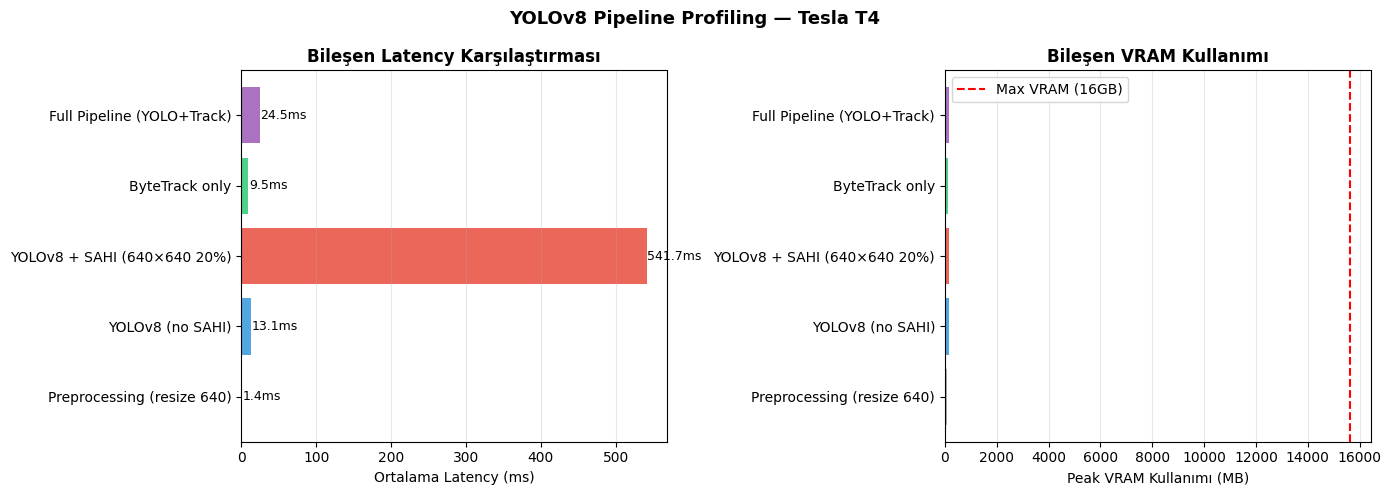

In [8]:
df = pd.DataFrame(results_table)
print('\n📊 Profiling Tablosu:')
print(df[['Component','Avg (ms)','Std (ms)','FPS','VRAM peak (MB)']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency bar
colors = ['#95a5a6','#3498db','#e74c3c','#2ecc71','#9b59b6']
axes[0].barh(df['Component'], df['Avg (ms)'], color=colors[:len(df)], alpha=0.85)
axes[0].set_xlabel('Ortalama Latency (ms)')
axes[0].set_title('Bileşen Latency Karşılaştırması', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
for i, (val, std) in enumerate(zip(df['Avg (ms)'], df['Std (ms)'])):
    axes[0].text(val + 0.5, i, f'{val:.1f}ms', va='center', fontsize=9)

# VRAM bar
axes[1].barh(df['Component'], df['VRAM peak (MB)'], color=colors[:len(df)], alpha=0.85)
axes[1].set_xlabel('Peak VRAM Kullanımı (MB)')
axes[1].set_title('Bileşen VRAM Kullanımı', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].axvline(x=TOTAL_VRAM*1000, color='red', linestyle='--', linewidth=1.5,
                label=f'Max VRAM ({TOTAL_VRAM:.0f}GB)')
axes[1].legend()

plt.suptitle(f'YOLOv8 Pipeline Profiling — {GPU_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/profiling_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5️⃣ Sonuçları Kaydet — Rapor için

In [9]:
profiling_summary = {
    'gpu':           GPU_NAME,
    'total_vram_gb': TOTAL_VRAM,
    'model':         MODEL_PATH,
    'imgsz':         640,
    'gflops':        round(gflops_yolo, 2),
    'params_m':      round(params_m_yolo, 2),
    'components':    df.to_dict(orient='records'),
}

prof_path = f'{PROJECT_DIR}/profiling_summary.json'
with open(prof_path, 'w') as f:
    json.dump(profiling_summary, f, indent=2)

df.to_csv(f'{PROJECT_DIR}/profiling_table.csv', index=False)

print('✅ Profiling sonuçları kaydedildi:')
print(f'   {prof_path}')
print(f'\n📋 Rapor için özet:')
print(f'   GPU         : {GPU_NAME}')
print(f'   VRAM total  : {TOTAL_VRAM:.1f} GB')
print(f'   GFLOPs      : {gflops_yolo:.2f}')
print(f'   Parameters  : {params_m_yolo:.2f}M')

full_row = df[df['Component'].str.contains('Full Pipeline')]
if not full_row.empty:
    print(f'   Full Pipeline FPS : {full_row["FPS"].values[0]:.1f}  (hedef: ~25 FPS)')
    print(f'   Full Pipeline VRAM: {full_row["VRAM peak (MB)"].values[0]:.1f} MB')

print('\n✅ GÜN 13 TAMAMLANDI!')

✅ Profiling sonuçları kaydedildi:
   /content/drive/MyDrive/DIP_Project/profiling_summary.json

📋 Rapor için özet:
   GPU         : Tesla T4
   VRAM total  : 15.6 GB
   GFLOPs      : 28.67
   Parameters  : 11.14M
   Full Pipeline FPS : 40.8  (hedef: ~25 FPS)
   Full Pipeline VRAM: 152.5 MB

✅ GÜN 13 TAMAMLANDI!


---
## ✅ Gün 13 Özet
| Metrik | Kaynak |
|--------|--------|
| GFLOPs | thop.profile() |
| VRAM | torch.cuda.max_memory_allocated() |
| Latency | perf_counter, 20 run ortalaması |
| FPS | 1000 / avg_latency_ms |

**Sonraki (Gün 14):** Hata analizi → `day14_error_analysis.ipynb`